In [1]:
from my_pkg.get_elevation_from_dsm import get_elevation_from_dsm, get_utm_3d_points_from_dsm
import cv2
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path
import os

from kornia.augmentation.auto.autoaugment.ops import color

from hloc.utils.viz import save_plot

os.environ['PROJ_LIB'] = '/home/lty/anaconda3/envs/hloc/share/proj'

from osgeo import gdal, osr
from geopy.distance import geodesic

from hloc import extract_features, match_features
from hloc.utils.io import get_matches, get_keypoints
from hloc.visualization import plot_images, plot_keypoints, plot_matches, read_image, add_text

/home/lty/anaconda3/envs/hloc/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


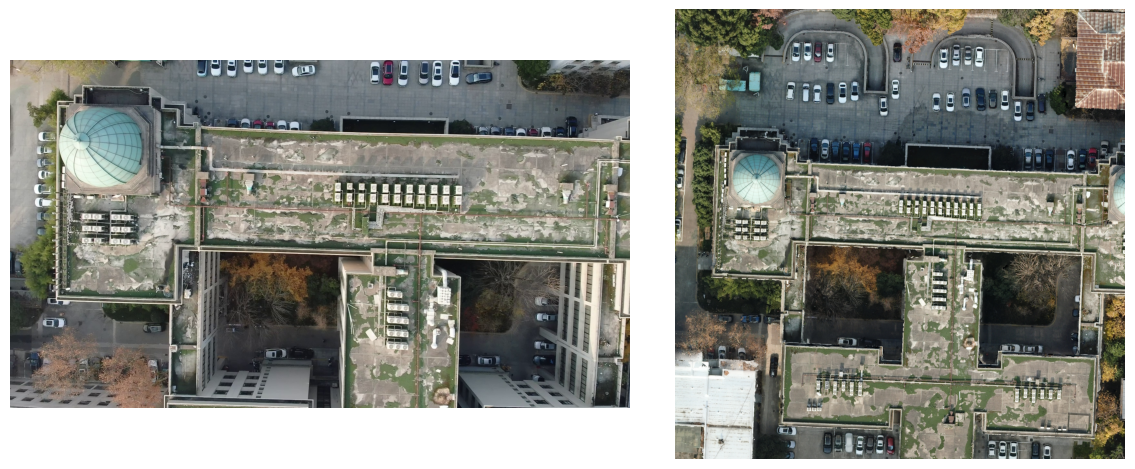

In [24]:
image_dir = Path("/home/lty/datasets_my/DJI/m300/")
img_1 = "seu_uav_12-26/01600.png"
img_2 = "seu_tif_m300_new/12_6600_0.tif"
# img_2 = "seu_uav/DJI_20250109085917_0001_W.JPG"
img_list = [img_1, img_2]
plot_images([read_image(image_dir / img_1), read_image(image_dir / img_2)])

In [25]:
output_dir = Path("../output_elevation_seu")
output_dir.mkdir(exist_ok=True, parents=True)
pairs_path = output_dir / "pairs.txt"

# for the first round of feature extraction and matching
features_1_path = output_dir / "features_1.h5"
matches_1_path = output_dir / "matches_1.h5"
# create pairs file
with open(pairs_path, 'w') as file:
    file.write(f"{img_1} {img_2}")

In [26]:
import time
t1 = time.time()
extract_features.main(
    conf=extract_features.confs["superpoint_max"],
    image_dir=image_dir,
    image_list=img_list,
    feature_path=features_1_path,
)
t2 = time.time()
match_features.main(
    conf=match_features.confs["superpoint+lightglue"],
    pairs=pairs_path,
    features=features_1_path,
    matches=matches_1_path,
)
t3 = time.time()
print(f"特征提取耗时：{t2 - t1:.2f} 秒")
print(f"特征匹配耗时：{t3 - t2:.2f} 秒")

[2025/05/22 16:41:27 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 3},
 'output': 'feats-superpoint-n4096-rmax1600',
 'preprocessing': {'grayscale': True, 'resize_force': True, 'resize_max': 1600}}


Loaded SuperPoint model


/home/lty/ch4/hloc/extractors/../../third_party/SuperGluePretrainedNetwork/models/superpoint.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch

特征提取耗时：0.75 秒
特征匹配耗时：1.25 秒


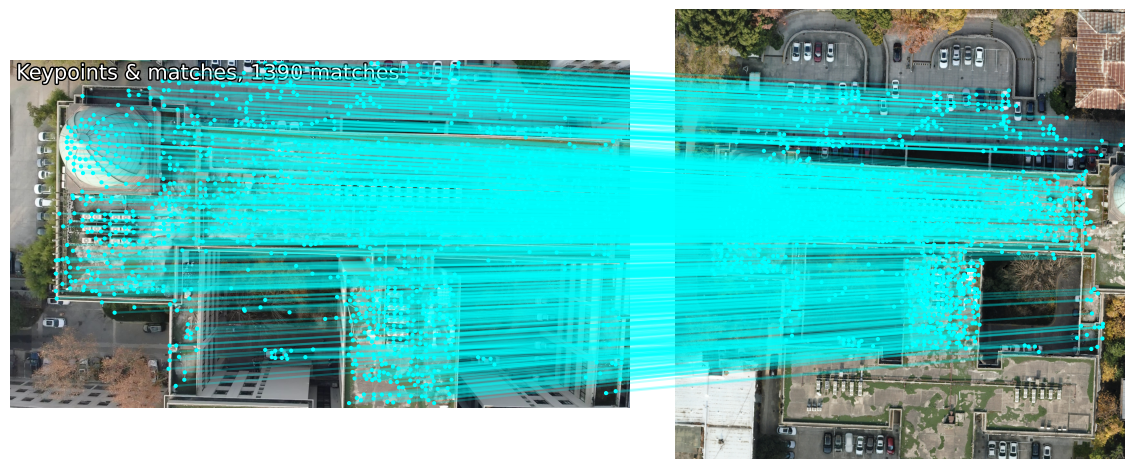

In [27]:
kp1, kp2  = get_keypoints(features_1_path, img_1), get_keypoints(features_1_path, img_2)
matches, scores = get_matches(matches_1_path, img_1, img_2)
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(kp1[matches[:,0]], kp2[matches[:,1]], a=0.25, color=(0, 1, 1))
add_text(0, f"Keypoints & matches, {matches.shape[0]} matches")
#save the plot
plt.savefig("matches.png", bbox_inches="tight", pad_inches=0, transparent=False)

[[-1.20250928e-08 -1.49809099e-06  7.03500414e-04]
 [ 1.49948293e-06 -2.07241810e-08 -1.45416095e-03]
 [-2.06633282e-03  2.20257238e-03  1.00000000e+00]]
533
内点数量：533/1390


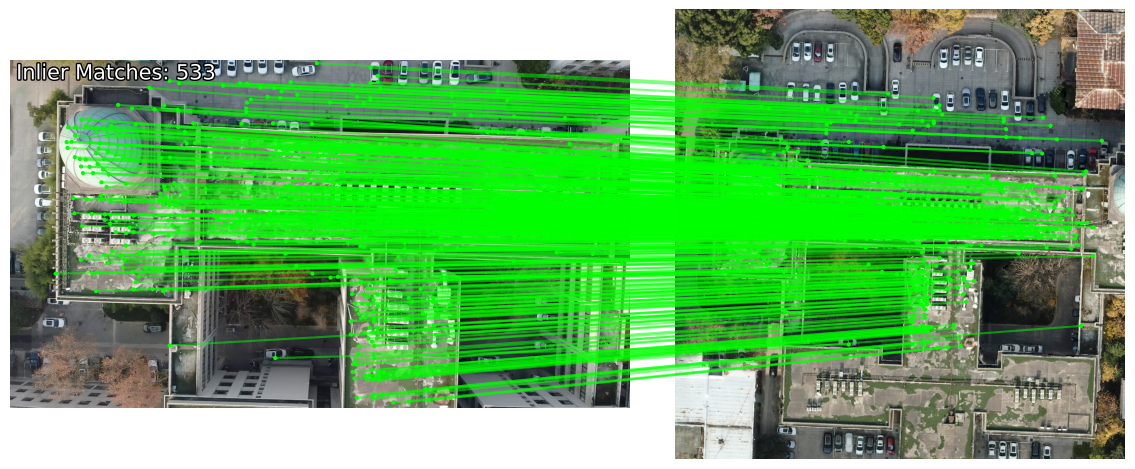

In [28]:
pts1 = kp1[matches[:, 0]]
pts2 = kp2[matches[:, 1]]

H, mask = cv2.findFundamentalMat(pts1, pts2, cv2.RANSAC, 1.5)  #mask:
print(H)
inliers = mask.ravel().tolist()
num_inliers = np.sum(inliers)
print(num_inliers)
# print(mask)

# 将 mask 转换为一维布尔数组
inliers = mask.ravel().astype(bool)

# 提取内点匹配对
pts1_inliers = pts1[inliers]
pts2_inliers = pts2[inliers]

# 提取外点匹配对（可选）
pts1_outliers = pts1[~inliers]
pts2_outliers = pts2[~inliers]

# 计算内点数量
num_inliers = np.sum(inliers)
print(f"内点数量：{num_inliers}/{len(pts1)}")

# 可视化内点匹配（例如，使用之前的 plot_matches 函数）
plot_images([read_image(image_dir / img) for img in img_list])
plot_matches(pts1_inliers, pts2_inliers, a=0.5, color=(0,1,0))
add_text(0, f"Inlier Matches: {num_inliers}")
plt.savefig("inlier_matches.png", bbox_inches="tight", pad_inches=0, transparent=False)

In [30]:
geotransform = []
# 打开 geotransform.txt 文件
with open("/home/lty/data/seu_geotransform_m300.txt", "r") as f:
    # 逐行读取文件内容
    for line in f:
        # 去除行首尾的空白字符和换行符
        line = line.strip()
        if line:
            try:
                # 将字符串转换为浮点数
                value = float(line)
                # 将数值添加到列表中
                geotransform.append(value)
            except ValueError:
                print(f"无法将以下内容转换为数值：'{line}'")
                # 根据需要，可以选择跳过或停止程序
                continue
# 输出读取到的 geotransform 数据
print("Geotransform 数组：\n", geotransform)

Geotransform 数组：
 [668601.89603705, 0.03459999999999788, 0.0, 3548451.1491134795, 0.0, -0.03459999999998963]


In [31]:
tif_name = os.path.basename(img_2)
print(tif_name)
start_x = start_y = None
# 使用正则表达式匹配以数字开头的部分
match = re.match(r"(\d+)_(\d+)_(\d+).tif", tif_name)
if match:
    tif_id = match.group(1)
    start_x = match.group(2)
    start_y = match.group(3)
    print(f"TIFF ID: {tif_id}")
    print(f"起始横坐标：{start_x}")
    print(f"起始纵坐标：{start_y}")
else:
    print("无法从文件名中提取 TIFF ID")
x_geo, y_geo = None, None
pts2_inliers_geo = np.zeros((len(pts2_inliers), 2))
pts2_inliers_geo_utm = np.zeros((len(pts2_inliers), 2))

# 保存转换后的地理坐标
# --------------------------
geo_out_path = output_dir / "satellite_inlier_points_with_geo.txt"
# 获取仿射变换参数
x_origin, x_pixel_size, x_rotation, y_origin, y_rotation, y_pixel_size = geotransform

lu_geox = x_origin + float(start_x) * x_pixel_size
lu_geoy = y_origin + float(start_y) * y_pixel_size



with open(geo_out_path, 'w') as f:
    for idx, (x_pix, y_pix) in enumerate(pts2_inliers): 
        x_in_map = int(start_x) + x_pix
        y_in_map = int(start_y) + y_pix
        
        x_geo = x_origin + x_in_map * x_pixel_size
        y_geo = y_origin + y_in_map * y_pixel_size
        
        pts2_inliers_geo_utm[idx, 0] = x_geo
        pts2_inliers_geo_utm[idx, 1] = y_geo
        
        x_geo = x_geo-lu_geox
        y_geo = y_geo-lu_geoy
        
        pts2_inliers_geo[idx, 0] = x_geo
        pts2_inliers_geo[idx, 1] = y_geo
        
        
        f.write(f"{idx} {x_pix:.2f} {y_pix:.2f} {x_geo:.8f} {y_geo:.8f}\n")

12_6600_0.tif
TIFF ID: 12
起始横坐标：6600
起始纵坐标：0


In [32]:
# print(pts2_inliers_geo)
print(lu_geox,lu_geoy)
# print(pts2_inliers_geo_utm)

668830.25603705 3548451.1491134795


In [33]:
# 指定输出文件路径
match_save_path = output_dir / "satellite_uav_inliers.txt"

# 打开文件写入模式
with open(match_save_path, 'w') as f:
    for idx, (pt2_geo, pt2, pt1) in enumerate(zip(pts2_inliers_geo, pts2_inliers, pts1_inliers)):
        # pt2: 卫星影像特征点（目标图像）
        # pt1: 无人机影像特征点（参考图像）
        x2_geo, y2_geo = pt2_geo
        x2, y2 = pt2  # 卫星影像
        x1, y1 = pt1  # 无人机影像
        # 写入格式：索引 x2 y2 x1 y1
        f.write(f"{idx} {x2_geo:.8f} {y2_geo:.8f} {x2:.2f} {y2:.2f} {x1:.2f} {y1:.2f}\n")

print(f"内点匹配信息已保存至 {match_save_path}")

内点匹配信息已保存至 ../output_elevation_seu/satellite_uav_inliers.txt


In [34]:
dsm_path = "/home/lty/data/SEU/dsm.tif"
satellite_3d_utm = get_utm_3d_points_from_dsm(dsm_path, pts2_inliers_geo_utm)

print(f"成功构建 3D 点集，共 {len(satellite_3d_utm)} 个点")
print(satellite_3d_utm)


成功构建 3D 点集，共 533 个点
[[6.68903608e+05 3.54840423e+06 3.34731903e+01]
 [6.68846881e+05 3.54841209e+06 4.47968140e+01]
 [6.68878523e+05 3.54840655e+06 3.35177841e+01]
 ...
 [6.68894820e+05 3.54840780e+06 3.39174805e+01]
 [6.68889768e+05 3.54843063e+06 1.08013000e+01]
 [6.68898453e+05 3.54840755e+06 3.38897552e+01]]


In [35]:
z_vals = satellite_3d_utm[:, 2].reshape(-1, 1)  # (N, 1)
satellite_3d_geo = np.hstack([pts2_inliers_geo, z_vals])  # (N, 3)
print(satellite_3d_geo)
#save
satellite_3d_geo_path = output_dir / "satellite_3d_geo.txt"
with open(satellite_3d_geo_path, 'w') as f:
    for idx, pt in enumerate(satellite_3d_geo):
        x, y, z = pt
        f.write(f"{x:.8f} {y:.8f} {z:.2f}\n")

[[ 73.352      -46.9176      33.47319031]
 [ 16.6253     -39.0634      44.79681396]
 [ 48.267      -44.5994      33.51778412]
 ...
 [ 64.5636     -43.3538      33.91748047]
 [ 59.512      -20.5178      10.80130005]
 [ 68.1966     -43.596       33.88975525]]


In [36]:
object_points = satellite_3d_geo.astype(np.float32)
# (N, 2) 无人机图像上的像素坐标
image_points = pts1_inliers.astype(np.float32)
fx, fy = 1543.468, 1543.468   # 焦距
cx, cy = 973.856, 533.855     # 主点

K = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
], dtype=np.float32)

In [37]:

import cv2
# solvePnP：用来估计R, t
success, rvec, tvec = cv2.solvePnP(
    objectPoints=object_points,
    imagePoints=image_points,
    cameraMatrix=K,
    distCoeffs=None,  # 无畸变时设为 None
    flags=cv2.SOLVEPNP_ITERATIVE  # 可换成 EPNP/DLS/UPnP 等
)
# success, rvec, tvec, inliers = cv2.solvePnPRansac(
#     objectPoints=object_points,
#     imagePoints=image_points,
#     cameraMatrix=K,
#     distCoeffs=None,
#     iterationsCount=100,
#     reprojectionError=5.0,  # 像素阈值
#     confidence=0.8,
#     flags=cv2.SOLVEPNP_ITERATIVE
# )
# 
# # 提取 RANSAC 选出的内点
# object_points_inliers = object_points[inliers[:, 0]]
# image_points_inliers = image_points[inliers[:, 0]]
# 
# # 使用内点进行 refine（非必须，但能更准）
# success, rvec, tvec = cv2.solvePnP(
#     object_points_inliers, image_points_inliers, K, None,
#     flags=cv2.SOLVEPNP_ITERATIVE
# )



if success:
    R, _ = cv2.Rodrigues(rvec)  # 将旋转向量转换为矩阵
    camera_center = -R.T @ tvec

    print("位姿估计成功！")
    print("旋转矩阵 R:\n", R)
    print("平移向量 t:\n", tvec.ravel())
    print("相机中心（世界坐标系）:\n", camera_center.ravel())
else:
    print("solvePnP 失败，可能是点分布不均或共面")

projected_points, _ = cv2.projectPoints(
    object_points, rvec, tvec, K, distCoeffs=None)

projected_points = projected_points.reshape(-1, 2)

reproj_error = np.linalg.norm(projected_points - image_points, axis=1)
print("平均重投影误差：", np.mean(reproj_error), "像素")

camerax_geo = lu_geox -tvec[0, 0]
cameray_geo = lu_geoy +tvec[1, 0]
print(tvec)
print(camera_center)
print(f"相机中心地理坐标: ({camerax_geo:.4f}, {cameray_geo:.4f})")

# 使用 Levenberg-Marquardt 方法进一步优化位姿
rvec_refined, tvec_refined = cv2.solvePnPRefineLM(
    objectPoints=object_points,
    imagePoints=image_points,
    cameraMatrix=K,
    distCoeffs=None,        # 如果有畸变，这里传入畸变参数
    rvec=rvec,              # 初始旋转向量
    tvec=tvec,               # 初始平移向量
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_COUNT, 100, 1e-9)
)

# 输出优化后的位姿
print("优化后的旋转向量 rvec_refined:\n", rvec_refined.ravel())
print("优化后的平移向量 tvec_refined:\n", tvec_refined.ravel())
R, _ = cv2.Rodrigues(rvec_refined)  # 将旋转向量转换为矩阵
camera_center = -R.T @ tvec_refined
print("优化后的相机中心（世界坐标系）:\n", camera_center.ravel())
camera_center_geo = camera_center.ravel() + np.array([lu_geox, lu_geoy, 0])
print(f"优化后的相机中心地理坐标: ({camera_center_geo[0]:.4f}, {camera_center_geo[1]:.4f})")

位姿估计成功！
旋转矩阵 R:
 [[ 0.99994635 -0.00950615 -0.00411537]
 [-0.00932766 -0.99909868  0.04141042]
 [-0.00450531 -0.04136981 -0.99913375]]
平移向量 t:
 [-50.39433205 -52.48797742 107.79166701]
相机中心（世界坐标系）:
 [ 50.38767349 -48.46040448 109.66444962]
平均重投影误差： 4.1669474 像素
[[-50.39433205]
 [-52.48797742]
 [107.79166701]]
[[ 50.38767349]
 [-48.46040448]
 [109.66444962]]
相机中心地理坐标: (668880.6504, 3548398.6611)
优化后的旋转向量 rvec_refined:
 [-3.10014856  0.01460355  0.00668439]
优化后的平移向量 tvec_refined:
 [-50.39433205 -52.48797742 107.79166701]
优化后的相机中心（世界坐标系）:
 [ 50.38767349 -48.46040448 109.66444962]
优化后的相机中心地理坐标: (668880.6437, 3548402.6887)
